# Candidate Generators

The Simple Ranker step built a solid ranker — but it gives **every user the same list**.
Alice (ML researcher) and Bob (frontend developer) see identical front pages.

The fix has two parts:
1. **Candidate generation** — select a smaller pool of stories that are plausibly
   relevant *for this user*, from the full 5 000-story corpus.
2. **A ranker that uses user signal** — rank that pool in a way that reflects the
   user's interests (the Ranker step).

This step handles personalization. We build four generators, each finding candidates a
different way, then combine their output into a single personalized pool.


In [1]:
import html
import json
import sys
from pathlib import Path

from IPython.display import HTML, display

_src = Path('../../../src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from ranking_service.interface import Context, Story, User
from ranking_service.impl_handrolled import HandrolledRankingService
from ranking_service.encoder import SentenceEncoder
from ranking_service.candidates import (
    ConnectedCandidateGenerator,
    ExplorationCandidateGenerator,
    KeywordCandidateGenerator,
    PopularityCandidateGenerator,
    SemanticCandidateGenerator,
)

/Users/dev/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/dev/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def show(stories, n=5, extra=None):
    """Render the first n stories as an HTML table.
    `extra` is an optional {column_name: fn(story) -> value} dict.
    """
    extra = extra or {}
    cols = list(extra.keys()) + ['points', 'title', 'author', 'comments']
    header = '<tr>' + ''.join(
        f'<th style="padding:4px 10px;text-align:left">{c}</th>' for c in cols
    ) + '</tr>'
    rows = []
    for s in stories[:n]:
        cells = []
        for fn in extra.values():
            val = fn(s)
            cells.append(f'{val:.3f}' if isinstance(val, float) else str(val))
        cells += [
            str(s.points),
            html.escape((s.title or '')[:80]),
            html.escape(s.author or ''),
            str(s.num_comments),
        ]
        rows.append('<tr>' + ''.join(
            f'<td style="padding:4px 10px">{c}</td>' for c in cells
        ) + '</tr>')
    display(HTML(f'<table>{header}{chr(10).join(rows)}</table>'))

### Load the snapshot

Same 5,000-story snapshot from the Simple Ranker step, now loaded into typed `Story` dataclasses.


In [3]:
snapshot_path = Path('../../../data').resolve() / 'hn_stories_snapshot.jsonl'
raw = [json.loads(l) for l in snapshot_path.read_text().splitlines() if l.strip()]

stories = [
    Story(
        id=r['id'],
        title=r['title'],
        url=r.get('url'),
        points=r.get('points') or 0,
        author=r['author'],
        created_at=r['created_at'],
        num_comments=r.get('num_comments') or 0,
        is_ask_hn=r.get('is_ask_hn', False),
        is_show_hn=r.get('is_show_hn', False),
        is_front_page=r.get('is_front_page', False),
    )
    for r in raw
]

print(f'{len(stories)} stories loaded')
show(stories, n=5)

5000 stories loaded


points,title,author,comments
1,India's Unconvincing Economic Facade,eatonphil,0
1,Russian politician says GTA 6 carries 'the stench of Americanism',HelloUsername,0
1,"Mu: A social app with a backbone, built on European values",modinfo,0
1,Eclipsa Video: HDR That Looks Right on Every Screen,ledoge,0
3,Claude Sonnet 5 System Card,adocomplete,0


---
### The problem: one ranking for everyone

Before we build anything new, let's confirm exactly what the Simple Ranker's does
with two users who have very different interests.


In [4]:
from datetime import datetime, timezone

_times = [datetime.fromisoformat(s.created_at.replace('Z', '+00:00')) for s in stories]
DATA_NOW = max(_times)

ctx = Context(timestamp=DATA_NOW.isoformat())
ranker = HandrolledRankingService()

alice = User(id='alice', interests=['machine learning', 'large language models', 'transformers', 'neural networks'])
bob   = User(id='bob',   interests=['trading', 'markets', 'finance', 'economics'])

display(HTML('<h4>Simple Ranker on all 5,000 stories — Alice (ML/AI interests)</h4>'))
show(ranker.rank(stories, alice, ctx), n=5)

display(HTML('<h4>Simple Ranker on all 5,000 stories — Bob (trading/finance interests)</h4>'))
show(ranker.rank(stories, bob, ctx), n=5)

points,title,author,comments
566,Claude Code Is Steganographically Marking Requests,kirushik,174
357,The labor share of income in the US is at its lowest post-war level,loughnane,337
150,County with 37 Data Centers Asks Schools to 'Conserve Electricity',01-_-,83
114,"EU commissioners shut down air conditioning for employees, leave theirs on",spwa4,92
609,European digital ID wallets rely on safety services of Google and Apple,donohoe,258


points,title,author,comments
566,Claude Code Is Steganographically Marking Requests,kirushik,174
357,The labor share of income in the US is at its lowest post-war level,loughnane,337
150,County with 37 Data Centers Asks Schools to 'Conserve Electricity',01-_-,83
114,"EU commissioners shut down air conditioning for employees, leave theirs on",spwa4,92
609,European digital ID wallets rely on safety services of Google and Apple,donohoe,258


**Finding**: identical lists. The HN decay formula only uses `points` and `age` —
the `user` argument is passed in but never read. No matter how different Alice and
Bob's interests are, they get the same front page.

Candidate generation fixes the first half of this: we change *who gets considered*
before the ranker even sees the list.


---
### What is candidate generation?

Each generator implements one interface:
```python
get_candidates(stories, user, n=500) -> List[Story]
```
Run several in parallel, merge, deduplicate — the ranker then works on a pool
that was shaped by who the user is, not just what's trending.

```
5 000 stories
    │
    ├─ Popularity  ──┐
    ├─ Semantic    ──┤  merge + dedup  →  ~1 000 candidates  →  ranker  →  top 30
    ├─ Exploration ──┤
    └─ Connected   ──┘
```


## Generator 1 — Popularity

The simplest baseline: return the most-upvoted stories. No user signal at all —
just ensures the pool always includes objectively trending content.


In [5]:
pop_gen = PopularityCandidateGenerator()
pop_candidates = pop_gen.get_candidates(stories, alice, n=500)

print(f'{len(pop_candidates)} candidates')
show(pop_candidates, n=5)

500 candidates


points,title,author,comments
1708,An entire Herculaneum scroll has been read for the first time,verditelabs,366
1348,Om Malik has died,minimaxir,171
1182,U.S. government will decide who gets to use GPT-5.6,alain94040,1233
1150,"The 'papers, please' era of the internet will decimate your privacy",bilsbie,615
1133,Previewing GPT‑5.6 Sol: a next-generation model,minimaxir,742


## Generator 2 — Semantic

Return stories close to the user's stated interests. We build this in two
steps — a fast keyword baseline first, then an upgrade to sentence embeddings
that understands meaning rather than just matching words.


### v1 — Keyword matching

The simplest approach: return stories whose titles contain any of the user's
interest words. No model, no training — just string matching.


In [6]:
kw_gen   = KeywordCandidateGenerator()
kw_alice = kw_gen.get_candidates(stories, alice)
kw_bob   = kw_gen.get_candidates(stories, bob)

display(HTML(f'<h4>Alice keyword candidates ({len(kw_alice)} stories)</h4>'))
show(kw_alice, n=5)

display(HTML(f'<h4>Bob keyword candidates ({len(kw_bob)} stories)</h4>'))
show(kw_bob, n=5)

points,title,author,comments
1,Guide to Using Large Language Models and Generative AI in Economic History,paulpauper,0
5,Efficiency in LLMs – Part 1 – Columbia Machine Learning Summer School 2026 [vide,matt_d,0
122,Knowledge Distillation of Black-Box Large Language Models (2024),babelfish,23
2,Transformers Explained for Software Engineers,bharadwajp,0
3,Graph of Thoughts: Solving Elaborate Problems with Large Language Models,simonpure,0


points,title,author,comments
1,An AI trading desk built as a team of sub-agents (Claude Code and Robinhood MCP),loganboyang,0
3,Global Energy Storage Growth Upheld by New Markets,toomuchtodo,1
3,"A Rust trading bot for Polymarket, 800µs decision loop",casatrick,0
2,The Search for El Dorado: How DS and ML Unlocked the Markets of Latin America,encinas88,0
3,"Mathematical finance, formally verified in Lean 4",raphaelrrcoelho,0


**Finding**: every result genuinely contains one of the interest words — precise.
But the ceiling is low. Stories about *"LLM training"*, *"attention mechanisms"*,
or *"gradient descent"* won't appear for Alice because none of those phrases
are in her interest list. Keyword matching only finds what it can literally see.


### v2 — Sentence embeddings

A sentence embedding model reads a full title and produces a single dense vector
where similar *meaning* lands in a similar *direction* — no word overlap required.

```
title → [transformer model] → 384-dim vector  (all values non-zero, no per-word labels)
```

We use **`BAAI/bge-small-en-v1.5`** via **fastembed**: ONNX-based, runs locally,
no PyTorch, no GPU, no API key. ~67 MB model downloaded once on first use.

**Retrieval**: each interest is embedded separately. A story's score is the
*maximum* similarity across all interests, so every interest gets equal weight
and a broad term can't drown out specific ones.


In [7]:
cache_path = Path('../../../data').resolve() / 'story_embeddings.npy'
encoder = SentenceEncoder(cache_path=cache_path).fit(stories)
print(f'Corpus: {encoder.n_stories} stories x {encoder.n_dims} dims')

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 5 files:  20%|██        | 1/5 [00:00<00:01,  2.68it/s]

Fetching 5 files:  40%|████      | 2/5 [00:03<00:05,  1.79s/it]

Fetching 5 files: 100%|██████████| 5/5 [00:03<00:00,  1.58it/s]

Loaded cached embeddings (story_embeddings.npy)
Corpus: 5000 stories x 384 dims


In [8]:
import numpy as np

# One story's embedding: dense, 384 dims, no word labels
sample_vec = encoder._matrix[0]
print(f'Story: "{stories[0].title}"')
print(f'Shape: {sample_vec.shape}  —  all {sample_vec.size} values non-zero')
print(f'First 8 values: {sample_vec[:8].round(4)}')
print(f'Norm:  {np.linalg.norm(sample_vec):.4f}  (unit vectors, so cosine = dot product)')
print()
print('No dimension maps to a specific word.')
print('The model compressed the full title meaning into 384 numbers.')

Story: "India's Unconvincing Economic Facade"
Shape: (384,)  —  all 384 values non-zero
First 8 values: [ 0.0347 -0.0294 -0.0474  0.0488  0.072  -0.0327  0.0503  0.0242]
Norm:  1.0000  (unit vectors, so cosine = dot product)

No dimension maps to a specific word.
The model compressed the full title meaning into 384 numbers.


In [9]:
sem_gen = SemanticCandidateGenerator(encoder)

alice_results = encoder.most_similar(alice.interests, top_k=10)
bob_results   = encoder.most_similar(bob.interests,   top_k=10)

alice_scores = {s.id: sc for s, sc in alice_results}
bob_scores   = {s.id: sc for s, sc in bob_results}

display(HTML(f'<h4>Alice — {", ".join(alice.interests)}</h4>'))
show([s for s, _ in alice_results], n=8, extra={'sim': lambda s, _d=alice_scores: _d[s.id]})

display(HTML(f'<h4>Bob — {", ".join(bob.interests)}</h4>'))
show([s for s, _ in bob_results], n=8, extra={'sim': lambda s, _d=bob_scores: _d[s.id]})

sim,points,title,author,comments
0.892,6,Large Language Models Are Overkill. Enter the Small Language Model,zerogpu,1
0.869,2,Tapered Language Models,sonabinu,0
0.868,122,Knowledge Distillation of Black-Box Large Language Models (2024),babelfish,23
0.855,3,Graph of Thoughts: Solving Elaborate Problems with Large Language Models,simonpure,0
0.813,223,"Apple Neural Engine: Architecture, Programming, and Performance",Jimmc414,27
0.812,1,Guide to Using Large Language Models and Generative AI in Economic History,paulpauper,0
0.805,3,Zero Weights Language Model (MSE-GLM),fodokidza,0
0.803,2,Qwen-AgentWorld: Language World Models for General Agents,shallow-mind,0


sim,points,title,author,comments
0.756,2,Vibe-Trading: Your Personal Trading Agent,grajmanu,0
0.743,1,EU Trade Explorer,abracadabrapouf,1
0.742,1,MarketNow,eddyflores,1
0.741,2,"Show HN: Apex Trading Signals – AI commodity trade ideas, free Android beta",dmaso191,0
0.732,4,Agentic Trading on Robinhood,huragok,2
0.725,3,"A Rust trading bot for Polymarket, 800µs decision loop",casatrick,0
0.724,2,Imali – an AI-assisted trading platform I built solo over the last 2 years,Griffjoy,0
0.722,3,Regent: A Differentiable Graph-Based Quant Trading Pipeline (VQ-VAE and GNNs),PanzerPeter,0


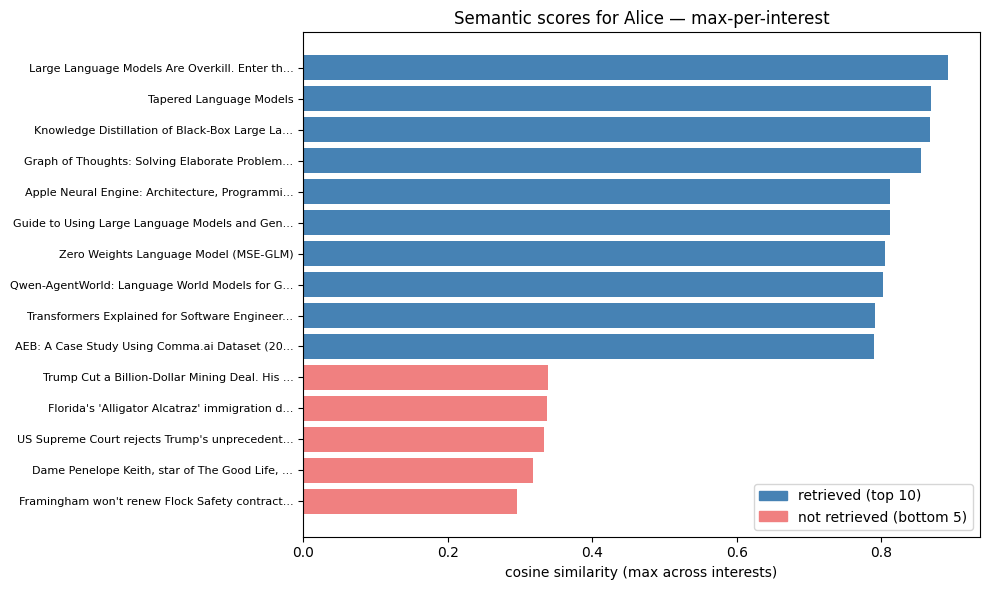

Score range: 0.892 (rank 1) -> 0.790 (rank 10) -> 0.296 (rank 5000)


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

all_alice     = encoder.most_similar(alice.interests, top_k=len(stories))
retrieved     = all_alice[:10]
not_retrieved = all_alice[-5:]

items  = list(retrieved) + list(not_retrieved)
labels = [(s.title[:44] + '...' if len(s.title) > 44 else s.title) for s, _ in items]
scores = [sc for _, sc in items]
colors = ['steelblue'] * 10 + ['lightcoral'] * 5

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(items)), scores, color=colors, edgecolor='none')
ax.set_yticks(range(len(items)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('cosine similarity (max across interests)')
ax.set_title('Semantic scores for Alice — max-per-interest')
ax.legend(handles=[
    mpatches.Patch(color='steelblue',  label='retrieved (top 10)'),
    mpatches.Patch(color='lightcoral', label='not retrieved (bottom 5)'),
], loc='lower right')
plt.tight_layout()
plt.show()
print(f'Score range: {scores[0]:.3f} (rank 1) -> {scores[9]:.3f} (rank 10) -> {scores[-1]:.3f} (rank {len(stories)})')

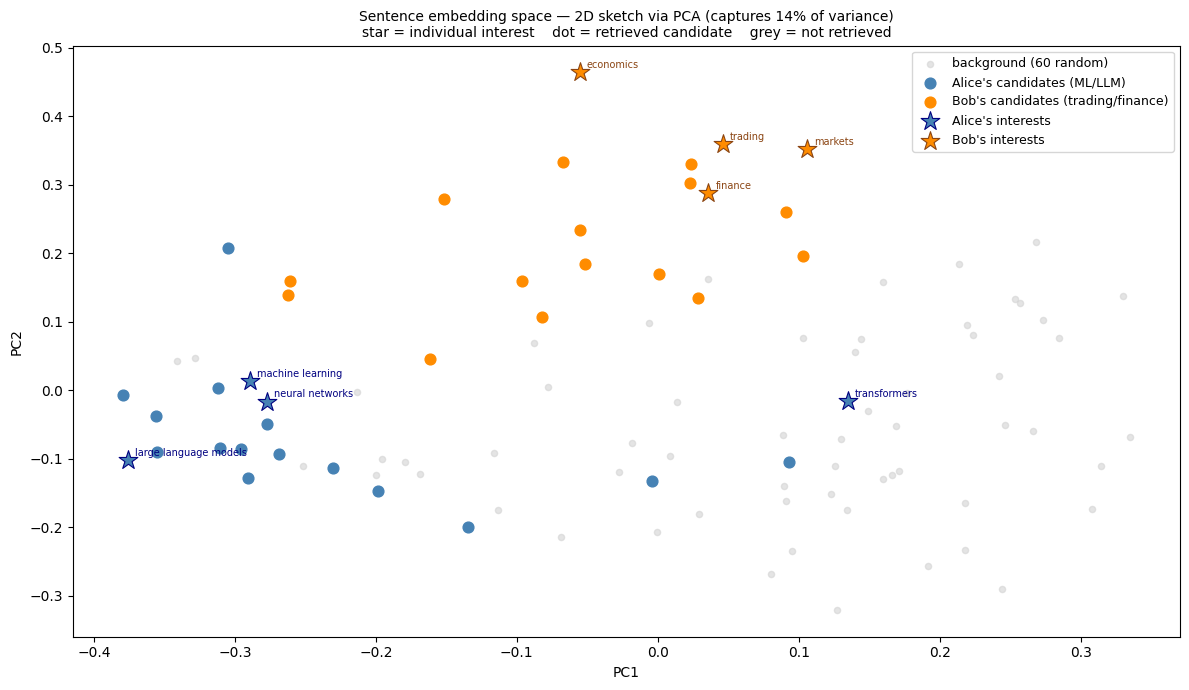

In [11]:
import random
from sklearn.decomposition import PCA

alice_top15 = encoder.most_similar(alice.interests, top_k=15)
bob_top15   = encoder.most_similar(bob.interests,   top_k=15)

both_ids  = {s.id for s,_ in alice_top15} | {s.id for s,_ in bob_top15}
id_to_idx = {s.id: i for i, s in enumerate(encoder._stories)}
bg_idx    = random.Random(99).sample(
    [i for i,s in enumerate(encoder._stories) if s.id not in both_ids], 60
)
alice_idx = [id_to_idx[s.id] for s,_ in alice_top15]
bob_idx   = [id_to_idx[s.id] for s,_ in bob_top15]

# Embed each interest separately so each gets its own point in the scatter
alice_ivecs = np.array(list(encoder._model.embed(alice.interests)))  # (4, 384)
bob_ivecs   = np.array(list(encoder._model.embed(bob.interests)))    # (4, 384)

all_vecs = np.vstack([
    encoder._matrix[alice_idx],
    encoder._matrix[bob_idx],
    encoder._matrix[bg_idx],
    alice_ivecs,
    bob_ivecs,
])

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(all_vecs)
var_pct = sum(pca.explained_variance_ratio_) * 100

na, nb_count = len(alice_idx), len(bob_idx)
ni_a, ni_b   = len(alice.interests), len(bob.interests)
alice_c  = coords[:na]
bob_c    = coords[na:na+nb_count]
bg_c     = coords[na+nb_count:na+nb_count+60]
alice_iq = coords[na+nb_count+60 : na+nb_count+60+ni_a]
bob_iq   = coords[na+nb_count+60+ni_a :]

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(bg_c[:,0],    bg_c[:,1],    c='lightgray',  s=20, alpha=0.6, label='background (60 random)')
ax.scatter(alice_c[:,0], alice_c[:,1], c='steelblue',  s=60, label="Alice's candidates (ML/LLM)")
ax.scatter(bob_c[:,0],   bob_c[:,1],   c='darkorange', s=60, label="Bob's candidates (trading/finance)")
ax.scatter(alice_iq[:,0], alice_iq[:,1], c='steelblue',  s=200, marker='*', zorder=5,
           edgecolors='navy', linewidths=0.8, label="Alice's interests")
ax.scatter(bob_iq[:,0],   bob_iq[:,1],   c='darkorange', s=200, marker='*', zorder=5,
           edgecolors='saddlebrown', linewidths=0.8, label="Bob's interests")

for i, interest in enumerate(alice.interests):
    ax.annotate(interest, alice_iq[i], fontsize=7, color='navy',
                xytext=(5, 3), textcoords='offset points')
for i, interest in enumerate(bob.interests):
    ax.annotate(interest, bob_iq[i], fontsize=7, color='saddlebrown',
                xytext=(5, 3), textcoords='offset points')

ax.set_title(
    f'Sentence embedding space — 2D sketch via PCA '
    f'(captures {var_pct:.0f}% of variance)\n'
    'star = individual interest    dot = retrieved candidate    grey = not retrieved',
    fontsize=10,
)
ax.legend(fontsize=9)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

**Finding**: the embedding retrieval catches semantically related content the
keyword filter would miss — stories about LLMs, attention mechanisms, and model
training appear for Alice even without those exact words in her interest list.

The two generators are complementary:
- **Keyword**: high precision, literal matches, fast
- **Semantic**: higher recall, meaning-aware, catches synonyms and related topics

Running both and merging the pools is more robust than either alone.

**Interest specificity matters**: vague terms like *"AI"* pull in broad cultural
commentary. Specific terms like *"large language models"* or *"neural networks"*
keep results focused on technical content. With sentence embeddings, narrower
interests give more useful signal.


## Generator 3 — Exploration

Popularity and semantic signals reinforce what users already know they like —
a filter bubble forms over time. The exploration generator is a **serendipity
engine**: it picks randomly from the long tail (low-points, under-exposed stories)
to surface content that would never break through on its own merits.

The key constraint: we exclude anything keyword or semantic would already return.
Without this, exploration might just rediscover Alice's ML stories — which defeats
the point. True exploration means stories *outside* the user's known interest space.


In [12]:
kw_ids   = {s.id for s in kw_alice}
sem_list = sem_gen.get_candidates(stories, alice, n=500)
sem_ids  = {s.id for s in sem_list}
known_ids = kw_ids | sem_ids

print(f'Keyword candidates  : {len(kw_ids):>4} stories  (title contains one of Alice\'s interest words)')
print(f'Semantic candidates : {len(sem_ids):>4} stories  (top-500 by cosine similarity)')
print(f'Union (excluded)    : {len(known_ids):>4} stories  — exploration will not touch any of these')
print(f'Remaining pool      : {len(stories) - len(known_ids):>4} stories  (candidate pool, filtered to ≤5 points below)')
print()
print('A few examples of what is excluded (semantic already covers these):')
for s in sem_list[:4]:
    print(f'  excluded  {s.title[:70]}')
print()

exp_gen = ExplorationCandidateGenerator(points_threshold=5, seed=42)
exp_candidates = exp_gen.get_candidates(stories, alice, n=50, exclude_ids=known_ids)

print(f'Exploration picks {len(exp_candidates)} stories from the remaining pool — none overlap with the above:')
show(exp_candidates, n=5)

Keyword candidates  :    7 stories  (title contains one of Alice's interest words)
Semantic candidates :  500 stories  (top-500 by cosine similarity)
Union (excluded)    :  500 stories  — exploration will not touch any of these
Remaining pool      : 4500 stories  (candidate pool, filtered to ≤5 points below)

A few examples of what is excluded (semantic already covers these):
  excluded  Large Language Models Are Overkill. Enter the Small Language Model
  excluded  Tapered Language Models
  excluded  Knowledge Distillation of Black-Box Large Language Models (2024)
  excluded  Graph of Thoughts: Solving Elaborate Problems with Large Language Mode

Exploration picks 50 stories from the remaining pool — none overlap with the above:


points,title,author,comments
1,"A Portrait of the Software Engineer, 2031",aesthetics1,0
2,They're in Their 60s and Their Student Loans Won't Let Them Retire,Vaslo,0
1,"Walter Mosley: ""A Novel is Not a Machine""",bookofjoe,0
3,Show HN: A field recording of the underground. The engineers and producers,shawnzam,1
1,Ask HN: Building a minimal to-do app based on Signal vs. Noise,simonhansson,1


## Generator 4 — Connected

Surface stories by authors whose work already resonates with the user.
The traversal has two steps:
1. **Seed**: find the top-N stories most similar to Alice's interests
2. **Expand**: collect all other stories written by those same authors

The intuition: if an author wrote something Alice would love, their other
work is a reasonable bet — a lightweight social graph signal without needing
explicit follow or like data.

The Storage step upgrades this to **Neo4j**: same traversal, but over a full
author-story engagement graph built from historical clicks and comments.


In [13]:
conn_gen = ConnectedCandidateGenerator(encoder=encoder, seed_top_k=20)
conn_candidates = conn_gen.get_candidates(stories, alice)

# Reconstruct the traversal so we can print each step
from collections import Counter
seed_results = encoder.most_similar(alice.interests, top_k=20)
seed_ids     = {s.id for s, _ in seed_results}
seed_authors = list(dict.fromkeys(s.author for s, _ in seed_results if s.author))

print('Step 1 — top-20 seed stories (highest cosine similarity to Alice\'s interests):')
for s, score in seed_results[:5]:
    print(f'  sim={score:.3f}  author={s.author:<20}  "{s.title[:55]}"')
print(f'  ... and {len(seed_results) - 5} more')
print()
print(f'Step 2 — unique authors extracted from those seeds:')
for author in seed_authors:
    n_stories = sum(1 for s in stories if s.author == author and s.id not in seed_ids)
    print(f'  {author:<25} → {n_stories} other stories in corpus')
print()
print(f'Step 3 — return all those stories as connected candidates: {len(conn_candidates)} total')
print(f'         (the 20 seed stories themselves are excluded to avoid duplicates)')
print()
show(conn_candidates, n=5)

Step 1 — top-20 seed stories (highest cosine similarity to Alice's interests):
  sim=0.892  author=zerogpu               "Large Language Models Are Overkill. Enter the Small Lan"
  sim=0.869  author=sonabinu              "Tapered Language Models"
  sim=0.868  author=babelfish             "Knowledge Distillation of Black-Box Large Language Mode"
  sim=0.855  author=simonpure             "Graph of Thoughts: Solving Elaborate Problems with Larg"
  sim=0.813  author=Jimmc414              "Apple Neural Engine: Architecture, Programming, and Per"
  ... and 15 more

Step 2 — unique authors extracted from those seeds:
  zerogpu                   → 0 other stories in corpus
  sonabinu                  → 1 other stories in corpus
  babelfish                 → 1 other stories in corpus
  simonpure                 → 2 other stories in corpus
  Jimmc414                  → 18 other stories in corpus
  paulpauper                → 35 other stories in corpus
  fodokidza                 → 0 other storie

points,title,author,comments
2,More on the depolarizing effects of current AI,paulpauper,0
2,Alex Ross is stepping down as music critic for The New Yorker,paulpauper,0
1,"Korinek, Autor, and Gimbel on AI and Jobs",paulpauper,0
1,New Glenn Return to Flight,LorenDB,0
4,Microsoft builds a bouncer to keep bots out of Teams meetings,LorenDB,1


---
### Combining generators

Run all generators for Alice and merge by deduplication on story id.
Each generator contributes a different signal; the combined pool is richer
than any one source alone.


In [14]:
kw_candidates  = kw_gen.get_candidates(stories, alice, n=500)
sem_candidates = sem_gen.get_candidates(stories, alice, n=500)

seen = set()
combined = []
for s in pop_candidates + kw_candidates + sem_candidates + exp_candidates + conn_candidates:
    if s.id not in seen:
        seen.add(s.id)
        combined.append(s)

print(f'Popularity : {len(pop_candidates):>4} candidates')
print(f'Keyword    : {len(kw_candidates):>4} candidates')
print(f'Semantic   : {len(sem_candidates):>4} candidates')
print(f'Exploration: {len(exp_candidates):>4} candidates')
print(f'Connected  : {len(conn_candidates):>4} candidates')
print(f'Combined   : {len(combined):>4} unique candidates  ({len(stories) - len(combined)} stories filtered out)')

Popularity :  500 candidates
Keyword    :    7 candidates
Semantic   :  500 candidates
Exploration:   50 candidates
Connected  :   95 candidates
Combined   : 1096 unique candidates  (3904 stories filtered out)


### Does the ranker actually use this personalization?

We have a personalized candidate pool shaped by Alice's ML interests.
But we're still using the Simple Ranker's HN decay formula to rank it — and that formula
reads only `points` and `age`, never `user`.

Two experiments to see if the personalization survives the ranking step:
1. Rank the **full combined pool** (popularity-dominated) with HN decay.
2. Rank only the **semantic pool** (Alice's interests directly) with the same ranker.


In [15]:
from ranking_service.impl_handrolled import _hn_score

ranked_combined = ranker.rank(combined,       alice, ctx)
ranked_sem_only = ranker.rank(sem_candidates, alice, ctx)

display(HTML(f'<h4>HN score on full combined pool ({len(combined)} candidates) — top 5 for Alice</h4>'))
show(ranked_combined, n=5, extra={'hn_score': lambda s: _hn_score(s, DATA_NOW)})

display(HTML(f'<h4>HN score on semantic-only pool ({len(sem_candidates)} candidates) — top 5 for Alice</h4>'))
show(ranked_sem_only, n=5, extra={'hn_score': lambda s: _hn_score(s, DATA_NOW)})

hn_score,points,title,author,comments
42.070,566,Claude Code Is Steganographically Marking Requests,kirushik,174
24.841,357,The labor share of income in the US is at its lowest post-war level,loughnane,337
12.996,150,County with 37 Data Centers Asks Schools to 'Conserve Electricity',01-_-,83
11.028,114,"EU commissioners shut down air conditioning for employees, leave theirs on",spwa4,92
10.839,609,European digital ID wallets rely on safety services of Google and Apple,donohoe,258


hn_score,points,title,author,comments
1.283,995,Age verification is just a precursor to automated attribution of speech,arkhiver,611
1.146,241,"LongCat-2.0, a large-scale MoE model with 1.6T total and 48B Active",benjiro29,67
0.919,191,Memory Safe Context Switching,modeless,29
0.674,250,Ornith-1.0: self-improving open-source models for agentic coding,danboarder,48
0.518,105,Exploring PDP-1 Lisp (1960),ozymandiax,23


## What we covered

| Generator | How it works | Key tradeoff |
|---|---|---|
| Popularity | Top-N by upvotes | Universal signal, zero personalization |
| Keyword | Title contains an interest word | High precision, limited recall |
| Semantic | Cosine similarity via sentence embeddings | High recall, catches synonyms and related topics |
| Exploration | Random from the low-points long tail, excluding known interests | Breadth and serendipity, low precision |

Running all four and merging gives the ranker both breadth (popularity, exploration)
and depth (keyword + semantic on the user's stated interests).

**The remaining gap**: the ranker is still the HN decay formula — it never reads the
`user` argument. The experiment above proved this: when popularity candidates dominate
the combined pool, the personalized semantic candidates get buried. Personalization in
the candidate pool is wasted without a ranker that scores based on who the user is.

A ranker that reads the user is **the Ranker step**. First, **the Storage step** replaces the
in-memory generators with production-scale backends — Elasticsearch, Qdrant, and
Neo4j — using the same generator interfaces. The retrieval logic stays identical;
only the storage layer changes.

**Finding**: the full combined pool's top-5 looks almost identical to the Simple Ranker step's
output — the popularity signal drowns out the keyword and semantic ones. High-points,
recent stories win regardless of Alice's interests.

The semantic-only pool tells a different story: the same decay formula, on a
smaller pool shaped by Alice's interests, surfaces content that is genuinely
ML/LLM-relevant.

This reveals the real gap: **candidate generation controls who gets *considered*,
but the ranker still can't distinguish an LLM story from a finance story**.
That's what The Ranker step fixes: a ranker that reads the user, not just the story.

---
**the Storage step first**: before we can train a smarter ranker, we need real storage.
The Storage step wires each generator to its production backend:
- `KeywordCandidateGenerator` → **Elasticsearch** (BM25 inverted index)
- `SemanticCandidateGenerator` → **Qdrant** (ANN search on the same fastembed vectors)
- `ConnectedCandidateGenerator` → **Neo4j** (author engagement graph)
The generator interfaces stay identical — only the backends change.
